# Momentum Investing Strategy in the Indian Stock Market

This notebook implements a momentum investing strategy based on the Nifty 50 stocks. The strategy selects the top 10 stocks with the highest 12-month volatility-adjusted returns and backtests the portfolio's performance against the Nifty 50 index over the last 10 years.

## 1. Setup and Data Download

In [1]:
!pip install yfinance pandas numpy matplotlib

In [2]:
# Nifty 50 tickers list as of a recent date.
# Note: This list is hardcoded and may need to be updated periodically.
nifty_50_tickers = [
    'ADANIENT.NS', 'ADANIPORTS.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AXISBANK.NS',
    'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BAJAJFINSV.NS', 'BPCL.NS', 'BHARTIARTL.NS',
    'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS', 'DIVISLAB.NS', 'DRREDDY.NS',
    'EICHERMOT.NS', 'GRASIM.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS',
    'HEROMOTOCO.NS', 'HINDALCO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'INDUSINDBK.NS',
    'INFY.NS', 'ITC.NS', 'JSWSTEEL.NS', 'KOTAKBANK.NS', 'LT.NS', 'LTIM.NS',
    'M&M.NS', 'MARUTI.NS', 'NESTLEIND.NS', 'NTPC.NS', 'ONGC.NS', 'POWERGRID.NS',
    'RELIANCE.NS', 'SBILIFE.NS', 'SBIN.NS', 'SUNPHARMA.NS', 'TATACONSUM.NS',
    'TATAMOTORS.NS', 'TATASTEEL.NS', 'TCS.NS', 'TECHM.NS', 'TITAN.NS',
    'ULTRACEMCO.NS', 'UPL.NS', 'WIPRO.NS'
]
# Add the Nifty 50 index ticker
benchmark_ticker = '^NSEI'

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Define the backtesting period (last 10 years)
end_date = datetime.now()
start_date = end_date - timedelta(days=10*365)

# Download historical data for Nifty 50 stocks and the benchmark
all_tickers = nifty_50_tickers + [benchmark_ticker]
data = yf.download(all_tickers, start=start_date, end=end_date)['Close']

# Separate stock and benchmark data
stock_data = data[nifty_50_tickers]
benchmark_data = data[benchmark_ticker]

print("Data downloaded successfully.")
stock_data.head()

[                       0%                       ]

[**                     4%                       ]  2 of 51 completed

[***                    6%                       ]  3 of 51 completed

[****                   8%                       ]  4 of 51 completed

[*****                 10%                       ]  5 of 51 completed

...

[*********************100%***********************]  51 of 51 completed



1 Failed download:


['TATAMOTORS.NS']: possibly delisted; no timezone found


Data downloaded successfully.


Ticker,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BAJAJFINSV.NS,BPCL.NS,BHARTIARTL.NS,...,SUNPHARMA.NS,TATACONSUM.NS,TATAMOTORS.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,ULTRACEMCO.NS,UPL.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-08,43.314945,228.692566,1358.400879,806.343872,403.690521,1823.394775,61.120228,199.062073,82.184555,276.462555,...,734.417603,129.223328,NaN,18.651917,963.223877,376.846436,334.547913,2596.504639,257.060242,96.072929
2016-01-11,43.499821,221.729462,1316.136597,805.652283,407.105865,1811.614136,61.039886,193.389969,80.774750,274.157593,...,723.412598,126.942116,NaN,18.508495,949.062073,366.128815,331.711945,2617.237061,256.727905,92.901031
2016-01-12,42.681057,224.761032,1316.717163,804.776550,396.274414,1799.219238,60.097122,194.793045,80.965752,269.248993,...,728.868774,124.795135,NaN,18.074558,934.880554,366.200989,333.490417,2562.767090,256.727905,94.880241
2016-01-13,42.707478,218.082108,1320.488892,800.765869,396.859863,1818.674438,58.829617,197.773438,81.488747,263.444031,...,736.683228,121.306244,NaN,18.137079,915.657349,364.071991,336.422546,2576.492676,248.389862,94.465378
2016-01-14,41.096371,215.808456,1331.562500,819.988953,381.149414,1813.110107,58.810738,193.937286,82.716667,263.572052,...,732.290588,119.919617,NaN,17.559719,915.496460,370.964386,328.491455,2521.255127,240.807083,94.249290


## 2. Momentum Score Calculation

In [4]:
def calculate_momentum_score(price_data):
    """
    Calculates the 12-month volatility-adjusted momentum score for each stock.
    
    Args:
        price_data (pd.DataFrame): DataFrame with stock prices for the calculation period.
        
    Returns:
        pd.Series: A series of momentum scores for each stock.
    """
    log_returns = np.log(price_data / price_data.shift(1))
    
    # Annual return
    momentum = (price_data.iloc[-1] - price_data.iloc[0]) / price_data.iloc[0]
    
    # Annualized volatility
    volatility = log_returns.std() * np.sqrt(252)
    
    # Momentum score
    momentum_score = momentum / volatility
    
    return momentum_score.dropna()

## 3. Backtesting the Strategy

In [5]:
portfolio_returns = {}
rebalance_dates = pd.date_range(start=stock_data.index.min() + pd.DateOffset(years=1), end=stock_data.index.max(), freq='YE')

for date in rebalance_dates:
    hold_end_date = date + pd.DateOffset(years=1)

    # Skip if the holding period extends beyond the available data, preventing partial year calculation
    if hold_end_date > stock_data.index.max():
        continue
        
    # Define calculation window (previous year)
    calc_end_date = date
    calc_start_date = date - pd.DateOffset(years=1)
    
    # Get data for calculation
    calc_data = stock_data.loc[calc_start_date:calc_end_date]
    
    # Calculate scores
    if len(calc_data) < 200:
        continue # Skip if not enough data
        
    momentum_scores = calculate_momentum_score(calc_data)
    
    # Select top 10 stocks
    top_10_stocks = momentum_scores.nlargest(10).index
    
    # Get data for holding period
    hold_data = stock_data.loc[date:hold_end_date]
    
    if hold_data.empty:
        continue
        
    # Calculate portfolio return for the year
    portfolio_subset = hold_data[top_10_stocks]
    daily_returns = portfolio_subset.pct_change().dropna()
    equal_weighted_returns = daily_returns.mean(axis=1)
    
    # Calculate cumulative return for the year
    annual_return = (1 + equal_weighted_returns).prod() - 1
    
    # Correctly label the return with the year of the holding period
    portfolio_returns[date.year + 1] = annual_return

# Convert to a pandas Series
portfolio_annual_returns = pd.Series(portfolio_returns)

print("Backtesting complete.")
portfolio_annual_returns

Backtesting complete.


2018    0.142464
2019    0.224920
2020    0.251459
2021    0.556032
2022   -0.077117
2023    0.333776
2024    0.096074
2025    0.046839
dtype: float64

## 4. Benchmark Performance

In [6]:
# Calculate benchmark annual returns
benchmark_annual_returns = benchmark_data.resample('YE').ffill().pct_change().dropna()
benchmark_annual_returns.index = benchmark_annual_returns.index.year

print("Benchmark performance calculated.")
benchmark_annual_returns

Benchmark performance calculated.


Date
2017    0.286460
2018    0.031513
2019    0.120220
2020    0.149016
2021    0.241193
2022    0.043290
2023    0.200278
2024    0.088048
2025    0.105089
2026    0.004619
Name: ^NSEI, dtype: float64

## 5. Results and Visualization

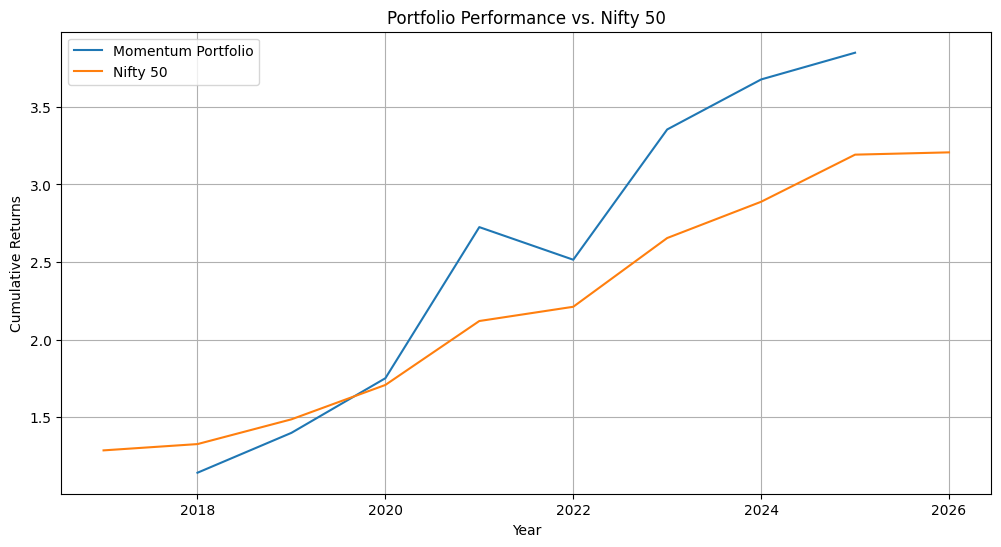

--- Performance Metrics ---
Momentum Portfolio CAGR: 18.35%
Nifty 50 CAGR: 12.36%
Momentum Portfolio Sharpe Ratio: 0.76
Nifty 50 Sharpe Ratio: 0.83


In [7]:
import matplotlib.pyplot as plt

# Calculate cumulative returns
cumulative_portfolio_returns = (1 + portfolio_annual_returns).cumprod()
cumulative_benchmark_returns = (1 + benchmark_annual_returns).cumprod()

# Plot cumulative returns
plt.figure(figsize=(12, 6))
cumulative_portfolio_returns.plot(label='Momentum Portfolio', legend=True)
cumulative_benchmark_returns.plot(label='Nifty 50', legend=True)
plt.title('Portfolio Performance vs. Nifty 50')
plt.xlabel('Year')
plt.ylabel('Cumulative Returns')
plt.grid(True)
plt.show()

# Performance metrics
def calculate_cagr(returns):
    num_years = len(returns)
    return returns.iloc[-1] ** (1 / num_years) - 1

def calculate_sharpe_ratio(returns, risk_free_rate=0.05):
    return (returns.mean() - risk_free_rate) / returns.std()

portfolio_cagr = calculate_cagr(cumulative_portfolio_returns)
benchmark_cagr = calculate_cagr(cumulative_benchmark_returns)

portfolio_sharpe = calculate_sharpe_ratio(portfolio_annual_returns)
benchmark_sharpe = calculate_sharpe_ratio(benchmark_annual_returns)

print("--- Performance Metrics ---")
print(f"Momentum Portfolio CAGR: {portfolio_cagr:.2%}")
print(f"Nifty 50 CAGR: {benchmark_cagr:.2%}")
print(f"Momentum Portfolio Sharpe Ratio: {portfolio_sharpe:.2f}")
print(f"Nifty 50 Sharpe Ratio: {benchmark_sharpe:.2f}")